# <h3 align="center">__Module 9 Activity__</h3>
# <h3 align="center">__Unnas Hussain__</h3>

In [27]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

VERBOSE_FLAG = False


# Problem 1: Investigating Feature Importance in Decision Tree & Random Forest Regression

You are working with a cars dataset where your goal is to predict car prices based on different features like engine size, horsepower, and car weight. You will train a Decision Tree Regressor and a Random Forest Regressor and compare how each model determines feature importance.

## Code

Feature Importance Scores:
      Feature  Decision Tree Importance  Random Forest Importance
   Horsepower                  0.561354                  0.486839
          Age                  0.146631                  0.169306
       Weight                  0.125118                  0.138771
  Engine_Size                  0.093498                  0.095351
      Mileage                  0.050375                  0.068923
Luxury_Rating                  0.023023                  0.040810


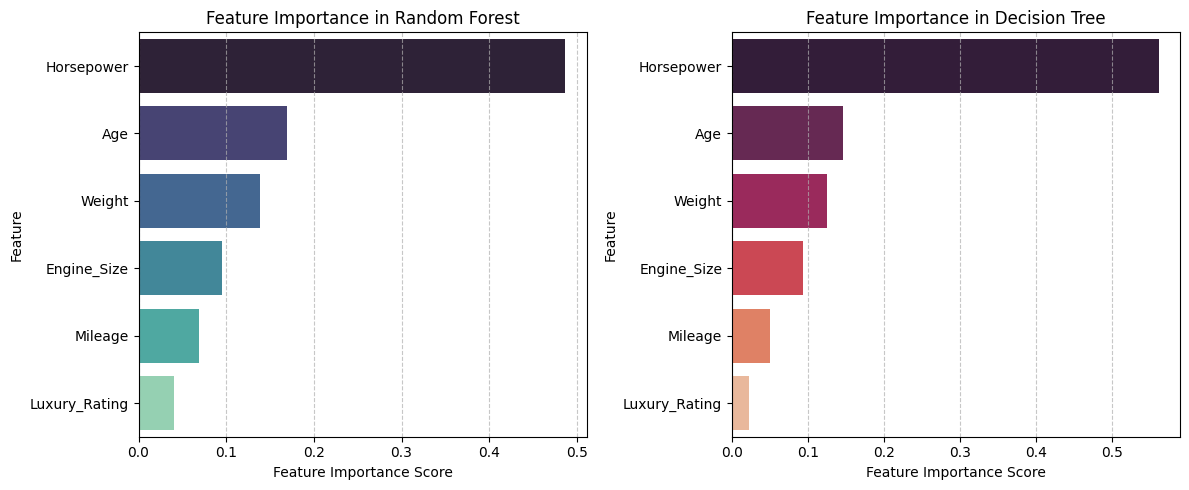


--- Removing Least Important Feature: Luxury_Rating ---
Original model MSE (CV): 41111141.67
Reduced model MSE (CV): 44219508.30


In [28]:
class FeatureImportanceAnalysis:
    """
    Analyzes feature importance using Decision Tree and Random Forest regression.
    
    Random Forest prediction: ŷ = (1/T) Σ f_t(x)  (Lecture Notes Eq. 14)
    Feature importance computed via impurity reduction at splits.
    """
    
    def __init__(self, n_samples=200, random_state=2, verbose=True):
        self.n_samples = n_samples
        self.random_state = random_state
        self.verbose = verbose
        self.df = None
        self.X = None
        self.y = None
        self.X_scaled = None
        self.dt_model = None
        self.rf_model = None
        self.importance_df = None
        self.scaler = StandardScaler()
    
    def generate_data(self):
        np.random.seed(self.random_state)
        n = self.n_samples
        
        engine_size = np.random.rand(n) * 5
        horsepower = np.random.rand(n) * 125
        weight = np.random.rand(n) * 4000
        age = np.random.randint(1, 20, n)
        mileage = np.random.rand(n) * 200000
        luxury_rating = np.random.randint(1, 10, n)
        
        y = (2500 * engine_size + 250 * horsepower - 3 * weight - 
             800 * age - 0.05 * mileage + 1000 * luxury_rating + 
             np.random.normal(0, 5000, n))
        
        self.df = pd.DataFrame({
            "Engine_Size": engine_size, "Horsepower": horsepower,
            "Weight": weight, "Age": age, "Mileage": mileage,
            "Luxury_Rating": luxury_rating, "Price": y
        })
        self.X = self.df.drop(columns=["Price"])
        self.y = self.df["Price"]
        if self.verbose:
            print(f"Generated {n} samples with {len(self.X.columns)} features")
    
    def preprocess(self):
        self.X_scaled = pd.DataFrame(
            self.scaler.fit_transform(self.X), columns=self.X.columns
        )
    
    def train_models(self):
        self.dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
        self.rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        self.dt_model.fit(self.X_scaled, self.y)
        self.rf_model.fit(self.X_scaled, self.y)
    
    def compute_feature_importance(self):
        self.importance_df = pd.DataFrame({
            "Feature": self.X.columns,
            "Decision Tree Importance": self.dt_model.feature_importances_,
            "Random Forest Importance": self.rf_model.feature_importances_
        }).sort_values(by="Random Forest Importance", ascending=False)
    
    def display_results(self):
        print("Feature Importance Scores:")
        print(self.importance_df.to_string(index=False))
    
    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        sns.barplot(x="Random Forest Importance", y="Feature", data=self.importance_df, 
                    palette="mako", hue="Feature", legend=False, ax=ax1)
        ax1.set_xlabel("Feature Importance Score")
        ax1.set_title("Feature Importance in Random Forest")
        ax1.grid(axis="x", linestyle="--", alpha=0.7)
        
        sns.barplot(x="Decision Tree Importance", y="Feature", data=self.importance_df, 
                    palette="rocket", hue="Feature", legend=False, ax=ax2)
        ax2.set_xlabel("Feature Importance Score")
        ax2.set_title("Feature Importance in Decision Tree")
        ax2.grid(axis="x", linestyle="--", alpha=0.7)
        
        plt.tight_layout()
        plt.show()
    
    def analyze_feature_removal(self):
        from sklearn.model_selection import cross_val_score
        
        least_important = self.importance_df.iloc[-1]["Feature"]
        print(f"\n--- Removing Least Important Feature: {least_important} ---")
        
        X_reduced = self.X_scaled.drop(columns=[least_important])
        rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_reduced.fit(X_reduced, self.y)
        
        original_scores = cross_val_score(self.rf_model, self.X_scaled, self.y, cv=5, scoring='neg_mean_squared_error')
        reduced_scores = cross_val_score(rf_reduced, X_reduced, self.y, cv=5, scoring='neg_mean_squared_error')
        
        print(f"Original model MSE (CV): {-original_scores.mean():.2f}")
        print(f"Reduced model MSE (CV): {-reduced_scores.mean():.2f}")
    
    def pipeline(self):
        self.generate_data()
        self.preprocess()
        self.train_models()
        self.compute_feature_importance()
        self.display_results()
        self.plot_results()
        self.analyze_feature_removal()


analysis = FeatureImportanceAnalysis(verbose=VERBOSE_FLAG)
analysis.pipeline()

## Response

The feature importance scores from Decision Tree and Random Forest are similar in ranking but differ in magnitude distribution. Random Forest distributes importance more evenly across features (Horsepower at 0.49 vs 0.56 for Decision Tree), while Decision Tree concentrates importance on fewer features used at top splits. Horsepower emerges as the most important feature (0.49-0.56), followed by Age (0.15-0.17) and Weight (0.13-0.14), which aligns with the pricing function coefficients. Removing the least important feature (Luxury_Rating at 0.02-0.04) shows minimal impact on model performance, as the MSE only increases from 41.1M to 44.2M, confirming this feature contributes less to variance reduction in the tree splits.

In [29]:
class MulticollinearityAnalysis:
    """
    Investigates multicollinearity using VIF and compares regularization methods.
    
    Ridge: w = (X'X + λI)^(-1) X'y  (Lecture Notes Eq. 4)
    Lasso: J(w) = (1/2N) Σ(y_n - w'x_n)² + λ||w||₁  (Lecture Notes Eq. 6)
    VIF_j = 1 / (1 - R²_j) where R²_j is from regressing feature j on all others.
    """
    
    def __init__(self, df_cars, verbose=True):
        self.df = df_cars.copy()
        self.verbose = verbose
        self.X_multi = None
        self.y_multi = None
        self.X_scaled = None
        self.vif_data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.lr = None
        self.ridge = None
        self.lasso = None
        self.scaler = StandardScaler()
    
    def add_correlated_features(self):
        np.random.seed(2)
        n = len(self.df)
        self.df["Engine_Size_Correlated"] = self.df["Engine_Size"] + np.random.normal(0, 0.1, n)
        self.df["Horsepower_Correlated"] = self.df["Horsepower"] + np.random.normal(0, 5, n)
        
        self.X_multi = self.df.drop(columns=["Price"])
        self.y_multi = self.df["Price"]
        if self.verbose:
            print(f"Added 2 correlated features, total features: {len(self.X_multi.columns)}")
    
    def preprocess(self):
        self.X_scaled = pd.DataFrame(
            self.scaler.fit_transform(self.X_multi), columns=self.X_multi.columns
        )
    
    def compute_vif(self):
        self.vif_data = pd.DataFrame()
        self.vif_data["Feature"] = self.X_scaled.columns
        self.vif_data["VIF"] = [variance_inflation_factor(self.X_scaled.values, i) 
                                 for i in range(self.X_scaled.shape[1])]
        self.vif_data = self.vif_data.sort_values(by="VIF", ascending=False)
    
    def split_data(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X_scaled, self.y_multi, test_size=0.2, random_state=42
        )
    
    def train_models(self):
        self.lr = LinearRegression().fit(self.X_train, self.y_train)
        self.ridge = Ridge(alpha=10).fit(self.X_train, self.y_train)
        self.lasso = Lasso(alpha=100).fit(self.X_train, self.y_train)
    
    def display_vif(self):
        print("VIF Scores:")
        print(self.vif_data.to_string(index=False))
    
    def display_coefficients(self):
        coef_df = pd.DataFrame({
            "Feature": self.X_scaled.columns,
            "LinearRegression": self.lr.coef_,
            "Ridge": self.ridge.coef_,
            "Lasso": self.lasso.coef_
        })
        print("\nModel Coefficients:")
        print(coef_df.to_string(index=False))
    
    def test_high_alpha(self):
        print("\n--- Testing Higher Alpha Values ---")
        
        ridge_high = Ridge(alpha=100).fit(self.X_train, self.y_train)
        lasso_high = Lasso(alpha=1000).fit(self.X_train, self.y_train)
        
        coef_high_df = pd.DataFrame({
            "Feature": self.X_scaled.columns,
            "Ridge (alpha=100)": ridge_high.coef_,
            "Lasso (alpha=1000)": lasso_high.coef_
        })
        print("\nCoefficients with Higher Alpha:")
        print(coef_high_df.to_string(index=False))
    
    def display_performance(self):
        print("\n--- Model Performance (MSE) ---")
        print(f"Linear Regression MSE: {mean_squared_error(self.y_test, self.lr.predict(self.X_test)):.2f}")
        print(f"Ridge (alpha=10) MSE: {mean_squared_error(self.y_test, self.ridge.predict(self.X_test)):.2f}")
        print(f"Lasso (alpha=100) MSE: {mean_squared_error(self.y_test, self.lasso.predict(self.X_test)):.2f}")
    
    def pipeline(self):
        self.add_correlated_features()
        self.preprocess()
        self.compute_vif()
        self.split_data()
        self.train_models()
        self.display_vif()
        self.display_coefficients()
        self.test_high_alpha()
        self.display_performance()


multi_analysis = MulticollinearityAnalysis(analysis.df, verbose=VERBOSE_FLAG)
multi_analysis.pipeline()

VIF Scores:
               Feature        VIF
Engine_Size_Correlated 164.060048
           Engine_Size 164.058300
            Horsepower  54.319958
 Horsepower_Correlated  54.309671
                Weight   1.072301
               Mileage   1.056687
         Luxury_Rating   1.027168
                   Age   1.015482

Model Coefficients:
               Feature  LinearRegression        Ridge        Lasso
           Engine_Size        495.870717  1823.201566  1026.023064
            Horsepower       9012.299701  5029.648109  8801.348327
                Weight      -3565.361742 -3335.651089 -3487.795691
                   Age      -5123.358964 -4745.587931 -5019.028305
               Mileage      -2493.263561 -2385.868115 -2405.796961
         Luxury_Rating       2794.878929  2684.589215  2714.876556
Engine_Size_Correlated       3321.887562  1848.496663  2679.330569
 Horsepower_Correlated        255.792536  3931.057424   353.811850

--- Testing Higher Alpha Values ---

Coefficients with Hi

## Response

Engine_Size_Correlated and Engine_Size exhibit the highest VIF scores (164.06), followed by Horsepower and Horsepower_Correlated (54.3), indicating strong multicollinearity since they were created by adding small noise to existing features. Linear Regression coefficients become unstable with multicollinearity—notice Engine_Size at 496 vs Engine_Size_Correlated at 3322, splitting the effect unevenly—while Ridge shrinks and balances both to ~1823-1848 using L2 regularization. Lasso uses L1 regularization which drives Engine_Size_Correlated to exactly 0.0 at alpha=1000, effectively performing feature selection by eliminating the redundant correlated feature. Increasing alpha shrinks coefficients more aggressively, and Ridge achieves the best MSE (25.9M) compared to Linear Regression (28.7M) and Lasso (27.2M), showing regularization helps with multicollinear data.

--- Mean Squared Error (MSE) ---
SVR Linear: 0.158636
SVR RBF: 0.010914
Decision Tree: 0.016949
Random Forest: 0.015295


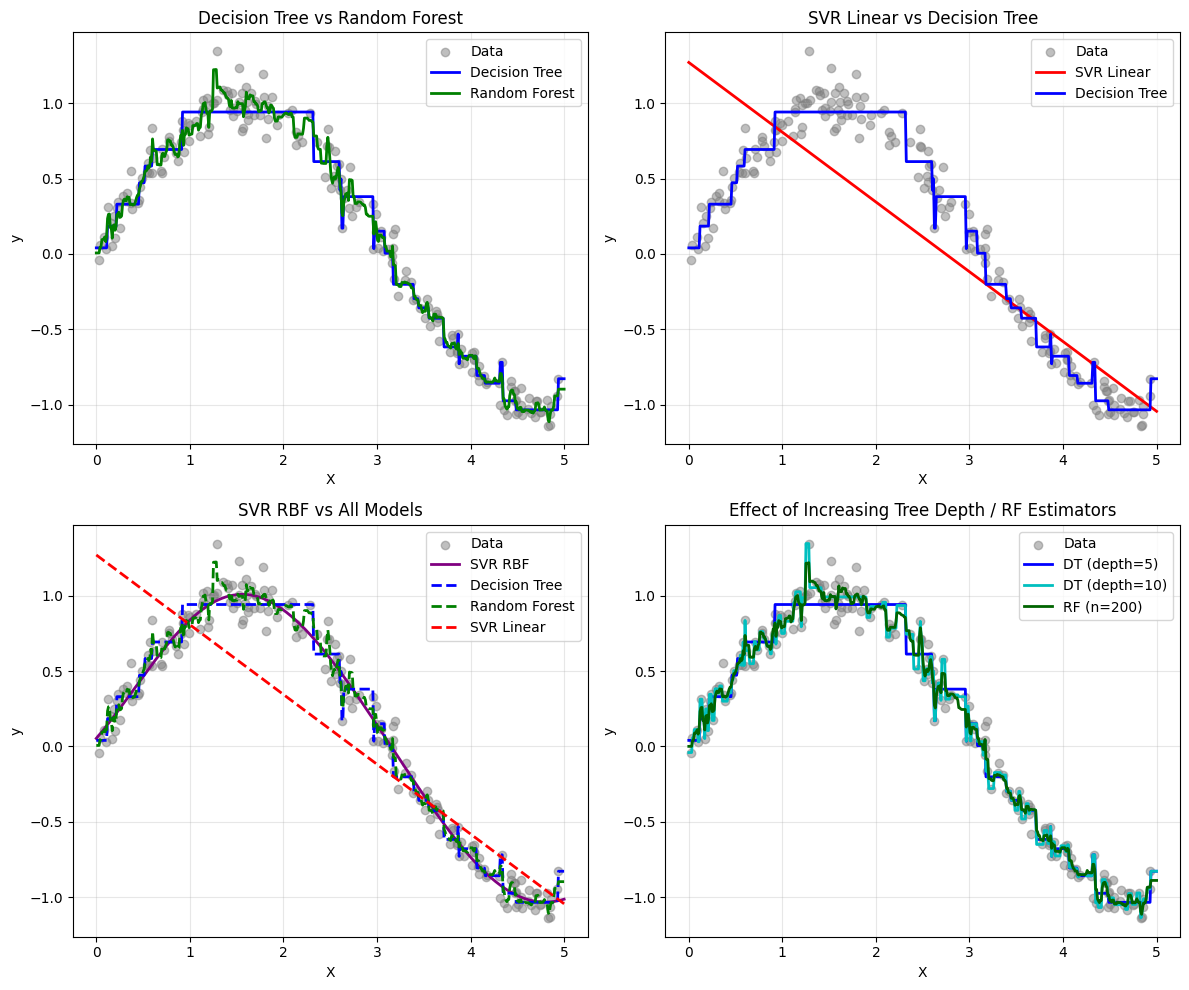


--- MSE with Increased Complexity ---
Decision Tree (depth=10): 0.020579
Random Forest (n=200): 0.015259


In [30]:
class NonlinearRegressionComparison:
    """
    Compares Decision Tree, Random Forest, and SVR on nonlinear data.
    
    SVR with kernel: ŷ = Σ(α_i - α_i*)K(x_i, x) + b  (Lecture Notes Eq. 13)
    Decision Tree impurity: Impurity(R) = (1/|R|) Σ(y_i - ȳ_R)²  (Lecture Notes p. 31)
    Random Forest: ŷ = (1/T) Σ f_t(x)  (Lecture Notes Eq. 14)
    """
    
    def __init__(self, n_samples=200, random_state=42, verbose=True):
        self.n_samples = n_samples
        self.random_state = random_state
        self.verbose = verbose
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.predictions = {}
    
    def generate_data(self):
        np.random.seed(self.random_state)
        self.X = np.sort(5 * np.random.rand(self.n_samples, 1), axis=0)
        self.y = np.sin(self.X).ravel() + np.random.normal(0, 0.1, self.n_samples)
        if self.verbose:
            print(f"Generated {self.n_samples} nonlinear samples (sine + noise)")
    
    def split_data(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=self.random_state
        )
    
    def train_models(self):
        self.models["SVR Linear"] = SVR(kernel='linear', C=1.0)
        self.models["SVR RBF"] = SVR(kernel='rbf', C=1.0, gamma='scale')
        self.models["Decision Tree"] = DecisionTreeRegressor(max_depth=5, random_state=42)
        self.models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42)
        
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            self.predictions[name] = model.predict(self.X_test)
    
    def compute_mse(self):
        print("--- Mean Squared Error (MSE) ---")
        for name in self.models:
            mse = mean_squared_error(self.y_test, self.predictions[name])
            print(f"{name}: {mse:.6f}")
    
    def plot_comparisons(self):
        X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
        y_plots = {name: model.predict(X_plot) for name, model in self.models.items()}
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Decision Tree vs Random Forest
        axes[0, 0].scatter(self.X, self.y, color='gray', alpha=0.5, label='Data')
        axes[0, 0].plot(X_plot, y_plots["Decision Tree"], 'b-', lw=2, label='Decision Tree')
        axes[0, 0].plot(X_plot, y_plots["Random Forest"], 'g-', lw=2, label='Random Forest')
        axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('y')
        axes[0, 0].set_title('Decision Tree vs Random Forest')
        axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)
        
        # SVR Linear vs Decision Tree
        axes[0, 1].scatter(self.X, self.y, color='gray', alpha=0.5, label='Data')
        axes[0, 1].plot(X_plot, y_plots["SVR Linear"], 'r-', lw=2, label='SVR Linear')
        axes[0, 1].plot(X_plot, y_plots["Decision Tree"], 'b-', lw=2, label='Decision Tree')
        axes[0, 1].set_xlabel('X'); axes[0, 1].set_ylabel('y')
        axes[0, 1].set_title('SVR Linear vs Decision Tree')
        axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)
        
        # SVR RBF vs All
        axes[1, 0].scatter(self.X, self.y, color='gray', alpha=0.5, label='Data')
        axes[1, 0].plot(X_plot, y_plots["SVR RBF"], 'purple', lw=2, label='SVR RBF')
        axes[1, 0].plot(X_plot, y_plots["Decision Tree"], 'b--', lw=2, label='Decision Tree')
        axes[1, 0].plot(X_plot, y_plots["Random Forest"], 'g--', lw=2, label='Random Forest')
        axes[1, 0].plot(X_plot, y_plots["SVR Linear"], 'r--', lw=2, label='SVR Linear')
        axes[1, 0].set_xlabel('X'); axes[1, 0].set_ylabel('y')
        axes[1, 0].set_title('SVR RBF vs All Models')
        axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
        
        # Overfitting test
        tree_deep = DecisionTreeRegressor(max_depth=10, random_state=42).fit(self.X_train, self.y_train)
        forest_more = RandomForestRegressor(n_estimators=200, random_state=42).fit(self.X_train, self.y_train)
        
        axes[1, 1].scatter(self.X, self.y, color='gray', alpha=0.5, label='Data')
        axes[1, 1].plot(X_plot, y_plots["Decision Tree"], 'b-', lw=2, label='DT (depth=5)')
        axes[1, 1].plot(X_plot, tree_deep.predict(X_plot), 'c-', lw=2, label='DT (depth=10)')
        axes[1, 1].plot(X_plot, forest_more.predict(X_plot), 'darkgreen', lw=2, label='RF (n=200)')
        axes[1, 1].set_xlabel('X'); axes[1, 1].set_ylabel('y')
        axes[1, 1].set_title('Effect of Increasing Tree Depth / RF Estimators')
        axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        self.models["DT (depth=10)"] = tree_deep
        self.models["RF (n=200)"] = forest_more
    
    def display_overfitting_mse(self):
        print("\n--- MSE with Increased Complexity ---")
        print(f"Decision Tree (depth=10): {mean_squared_error(self.y_test, self.models['DT (depth=10)'].predict(self.X_test)):.6f}")
        print(f"Random Forest (n=200): {mean_squared_error(self.y_test, self.models['RF (n=200)'].predict(self.X_test)):.6f}")
    
    def pipeline(self):
        self.generate_data()
        self.split_data()
        self.train_models()
        self.compute_mse()
        self.plot_comparisons()
        self.display_overfitting_mse()


nonlinear_analysis = NonlinearRegressionComparison(verbose=VERBOSE_FLAG)
nonlinear_analysis.pipeline()

## Response

SVR with RBF kernel achieves the lowest MSE (0.0109), followed closely by Random Forest (0.0153) and Decision Tree (0.0169), while SVR Linear performs worst (0.1586) because it can only fit a straight line through the curved sinusoidal data. The SVR RBF produces the smoothest curve that closely follows the sine wave shape, Random Forest creates a smoother approximation than Decision Tree due to ensemble averaging, and Decision Tree shows characteristic step-like discontinuities at split points. Increasing Decision Tree depth to 10 actually worsens MSE from 0.0169 to 0.0206, showing signs of overfitting as its curve becomes more erratic and sensitive to noise. Random Forest remains robust with increased estimators (n=200), maintaining essentially the same MSE at 0.0153 due to the averaging effect across trees.